In [2]:
import astropy.constants as acon
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
import astropy.constants as acon
from helper import *

In [3]:
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel

# One or many times
t = Time("2013-06-22 00:00:00")  # or Time(np.linspace(...), format='jd') for an array

pos, vel = get_body_barycentric_posvel('earth', t)

# pos, vel are CartesianRepresentation in ICRS frame (barycentric)
r_xyz = pos.xyz.to('km')        # position vector, [x, y, z]
v_xyz = vel.xyz.to('km/s')      # velocity vector, [vx, vy, vz]

In [4]:
pos_earth, vel_earth = get_body_barycentric_posvel('earth', t)
pos_sun, vel_sun     = get_body_barycentric_posvel('sun', t)

r_helio = pos_earth - pos_sun     # Earth position relative to Sun
v_helio = vel_earth - vel_sun     # Earth velocity relative to Sun (this is V_⊕(t) in the paper)

In [5]:
from astropy.coordinates import HeliocentricMeanEcliptic, SkyCoord

coord = SkyCoord(pos_earth, frame='icrs', representation_type='cartesian', obstime=t)
ecl = coord.transform_to(HeliocentricMeanEcliptic(obstime=t))

In [16]:
from vel_conversions import *

In [173]:
t0 = Time("2013-06-22 00:00:00")

times = t0 + np.linspace(0, 30, 1000) * u.day + 0 * u.day

In [174]:
site = EarthLocation(lat=51.4779 * u.deg, lon=-0.0015 * u.deg, height=45 * u.m)
start  = sun_to_lab_position(t0, site, frame="ecliptic")
res = sun_to_lab_position(times, site, frame="ecliptic")

In [175]:
from scipy.optimize import minimize
import astropy.constants as acon

def grav(x):
    '''
    Returns potential at a certain distance from the Sun
    @param x The distance from the Sun, in kilometres.
    '''
    return - acon.G.value * 1e-9 * acon.M_sun.value / x

def jacobian_closed_form(u, Phi, theta):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    #v = np.asarray(v, dtype=float)
    v = np.sqrt(u*u + 2*Phi)
    vdotr = v * np.cos(theta)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)

def theta_inf(theta, u, Phi):
    v = np.sqrt(u*u + 2 * Phi)
    numer = v * np.sin(theta) * (u - v * np.cos(theta))
    denom = u * v * np.cos(theta) - (v*np.cos(theta))**2 + Phi
    tan = numer/denom
    
    angle = np.arctan(tan)
    if angle < 0:
        angle = np.pi + angle
        
    return angle

def func(theta, u, Phi, thetainf):
    return np.abs(theta_inf(theta, u, Phi) - thetainf)


In [176]:
spd = 220

vel_str = (spd * start[0] / start[1]).value
vlab = res[2].value.T
speed = res[3].value
r = res[0].value.T
dist = res[1].value
theta = np.sum(vel_str * r, axis=1) / dist / np.linalg.norm(vel_str)
theta = np.arccos(theta)
Phi = -grav(dist)

spd_loc = np.sqrt(spd*spd + 2 * Phi)

#v_loc = 220 * np.array((np.cos(theta), np.sin(theta), np.zeros_like(theta))).T - vlab

In [177]:
def rotation(t):
    return np.row_stack(([np.cos(t), -np.sin(t), 0],
                     [np.sin(t), np.cos(t), 0],
                     [0, 0, 1]))

def rotationz(t):
    return np.row_stack(([np.cos(t), 0, np.sin(t)],
                     [0, 1, 0],
                     [-np.sin(t), 0, np.cos(t)]))

In [178]:
dens = []
vloc1 = []
vloc2 = []
dens1 = []
dens2 = []
for i in range(theta.shape[0]):
    spd = np.linalg.norm(vel_str)
    spd_loc = np.sqrt(spd*spd + 2 * Phi[i])
    p = theta[i]
    ang1 = minimize(func, x0 = np.arccos(spd/spd_loc), bounds = [(np.arccos(spd/spd_loc), np.pi)], args=(spd, Phi[i], p)).x[0]
    ang2 = minimize(func, x0 = 0, bounds = [(0,np.arccos(spd/spd_loc))], args=(spd, Phi[i], np.pi - p)).x[0]
    
    assert func(ang1, spd, Phi[i], p) < 1e-6
    assert func(ang2, spd, Phi[i], np.pi - p) < 1e-6

    v_loc = spd_loc * rotation(-ang1) @ r[i] / dist[i] - vlab[i]
    vloc1.append(np.linalg.norm(v_loc))

    v_loc = spd_loc * rotation(ang2) @ r[i] / dist[i] - vlab[i]
    vloc2.append(np.linalg.norm(v_loc))

    dens1.append(1 / jacobian_closed_form(spd, Phi[i], ang1))
    dens2.append(1 / jacobian_closed_form(spd, Phi[i], ang2))
    
    #den = 1 / jacobian_closed_form(spd, Phi[i], ang1) + 1 / jacobian_closed_form(spd, Phi[i], ang2)

vloc1 = np.array(vloc1)
dens1 = np.array(dens1)
vloc2 = np.array(vloc2)
dens2 = np.array(dens2)

dens = dens1 + dens2


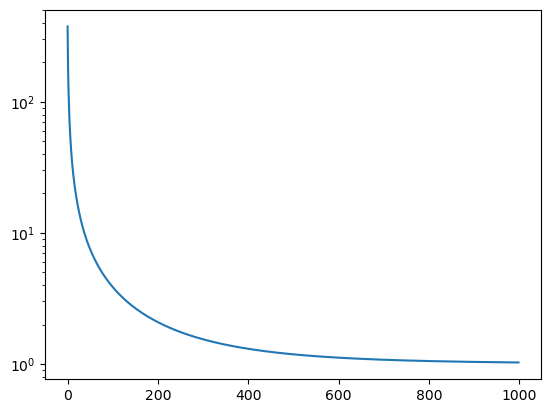

In [179]:
plt.semilogy(dens[1:])

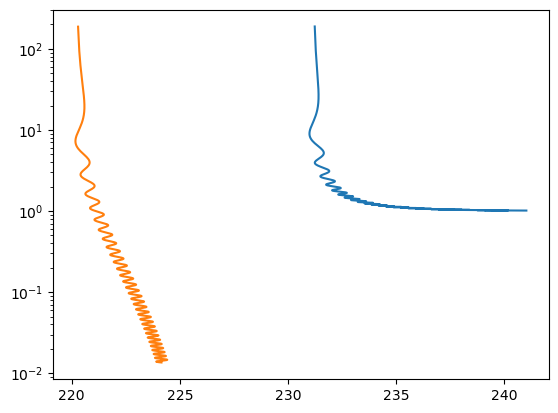

In [ ]:
plt.semilogy(vloc1[1:-1], dens1[1:-1])
plt.semilogy(vloc2[1:-1], dens2[1:-1])
#plt.yscale("log") 


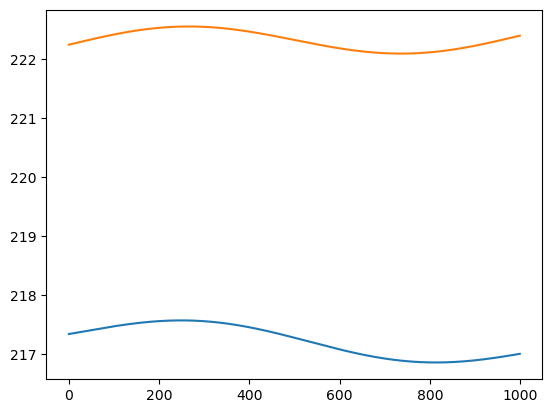

In [169]:
plt.plot(vloc1)
plt.plot(vloc2)